In [16]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import pickle
import json
import sys
sys.path.append("../../../")


from src.dataset_manager import DatasetConvertor 
from src.context_free.config import ModelConfig, TrainingConfig, MetaConfig
from src.context_free.preprocessing import PreprocessingDataset
from src.context_free.models import createModel
from src.context_free.training import trainModel
from src.context_free.evaluation import evaluateModel

In [ ]:
def save_predictions_to_csv(actual, predicted, sampling_time, output_dir, name, dataset_type):
    timestamps = np.arange(len(actual)) * sampling_time
    
    df = pd.DataFrame({
        'timestamp': timestamps,
        'actual': actual.flatten(),
        'predicted': predicted.flatten()
    })
    
    os.makedirs(output_dir, exist_ok=True)
    output_path = f"{output_dir}/{name}_{dataset_type}_predictions.csv"
    df.to_csv(output_path, index=False)
    print(f"{dataset_type.capitalize()} predictions saved to: {output_path}")
    return df

In [17]:
rawDatasetFolder = "../../../data/raw"
configPath = "../../config/combined_flows_forward_1ms_20.json"
modelFolder = "../../../data/models/context_free"
trafficDataFolder = "../../../data/processed/dpdr"
verbose = True

In [18]:
config = json.load(open(configPath))
name = config.get("NAME")
len_window = config.get("LEN_WINDOW")
dim_data =  len(config.get("CONTEXT_IDXS"))

In [19]:
datasetConverter = DatasetConvertor(rawDatasetFolder, randomFlag=False)
with open(configPath, "r") as f:
    config = json.load(f)

name = config.get("NAME")
len_window = config.get("LEN_WINDOW")
dim_data = len(config.get("CONTEXT_IDXS"))
train_ratio = config.get("TRAIN_RATIO")

# =============== Preprocessing ===============
datasetConverter.addDataUnit(config)
dataUnit = datasetConverter.getDataUnit(name)
max_vals, min_vals = dataUnit.getMaxMinMbnVals()
metaConfig = MetaConfig.initialize(
    dim_data=dim_data, 
    len_window=len_window
)
metaConfig.save(f"{modelFolder}/{name}_metaConfig.json")

trainDataUnit, testDataUnit = dataUnit.split(train_ratio)
dataProcessor = PreprocessingDataset(metaConfig)
trainData = dataProcessor.process(trainDataUnit, dataAugment=False)
testData = dataProcessor.process(testDataUnit, dataAugment=False)

In [21]:
modelConfig = ModelConfig.load(f"{modelFolder}/{name}_modelConfig.json")
model, device = createModel(modelConfig)
model.load_checkpoint(f"{modelFolder}/{name}.pth")

actual_train, predicted_train = evaluateModel(model, trainData)
actual_test, predicted_test = evaluateModel(model, testData)

sampling_time = config.get("SAMPLING_TIME")
output_dir = "../../../data/predict_dataset"

train_df = save_predictions_to_csv(actual_train, predicted_train, sampling_time, output_dir, name, "train")
test_df = save_predictions_to_csv(actual_test, predicted_test, sampling_time, output_dir, name, "test")


Train predictions saved to: ../../../data/predict_dataset/combined_flows_forward_1ms_20_train_predictions.csv
Test predictions saved to: ../../../data/predict_dataset/combined_flows_forward_1ms_20_test_predictions.csv


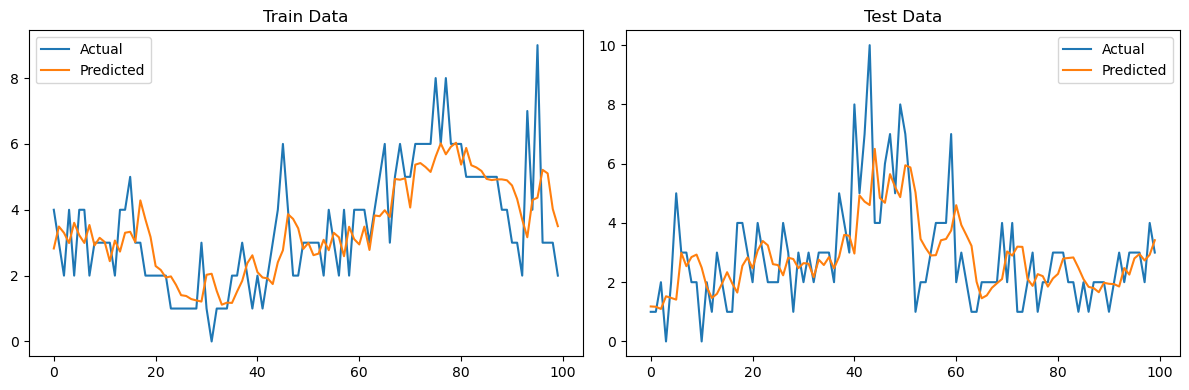

In [22]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(actual_train[0:100], label='Actual')
plt.plot(predicted_train[0:100], label='Predicted')
plt.title('Train Data')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(actual_test[0:100], label='Actual')
plt.plot(predicted_test[0:100], label='Predicted')
plt.title('Test Data')
plt.legend()

plt.tight_layout()
plt.show()
